In [1]:
print("Here begins the data overview notebook.")

Here begins the data overview notebook.


In [2]:
# Canadian Health Survey (2019-2020) – Data Overview & Preprocessing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load dataset, set display options, show first few rows
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/raw/global_mental_health_patterns/life_satisfaction_canadian_survey.csv")
df.head()

,ADM_RNO1,Province,Health_region_ grouped,Gender,Marital_status,Household,Age,Worked_job_business,Edu_level,Gen_health_state,Life_satisfaction,Mental_health_state,Stress_level,Work_stress,Sense_belonging,Weight_state,BMI_12_17,BMI_18_above,Sleep_apnea,High_BP,High_cholestrol,Diabetic,Fatigue_syndrome,Mood_disorder,Anxiety_disorder,Respiratory_chronic_con,Musculoskeletal_con,Cardiovascular_con,Health_utility_indx,Pain_status,Act_improve_health,Fruit_veg_con,Smoked,Tobaco_use,weekly_alcohol,Cannabies_use,Drug_use,Total_active_time,Total_physical_act_time,Other_physical_act_time,Physical_vigorous_act_time,Work_hours,working_status,Aboriginal_identity,Birth_country,Immigrant,Insurance_cover,Food_security,Income_source,Total_income
0,1000,47,47906,2,1,2,3,1,3,3,9,3,2,2,2,3,6,2,2,2,2,2,2,2,2,2,2,2,1,2,6,1.3,996.0,6,996,2,2,0,0,60,10,38,1,2,1,2,1,0,1,5
1,100005,47,47906,1,1,2,5,6,2,3,4,3,3,6,3,1,6,2,1,1,2,2,2,1,2,2,2,2,9,1,6,1.0,996.0,6,996,2,2,0,0,0,0,96,6,2,1,2,1,0,2,4
2,100012,59,59914,2,2,1,5,6,1,2,7,3,3,6,2,1,6,2,2,1,2,1,2,2,2,1,1,2,1,1,6,9999.6,996.0,2,996,2,2,9996,9996,9996,9996,96,6,2,1,2,6,6,2,2
3,100015,13,13904,1,2,1,5,6,1,3,8,3,3,6,2,1,6,2,2,1,2,2,2,2,2,2,1,2,2,1,6,9999.6,996.0,6,996,2,6,9996,9996,9996,9996,96,6,2,1,2,6,0,2,3
4,100018,46,46903,1,2,1,4,2,3,5,0,5,4,6,3,3,6,2,2,1,2,9,2,2,2,9,1,9,1,2,6,9999.6,996.0,6,996,2,2,9996,9996,9996,9996,96,6,2,1,2,2,0,2,1


In [3]:
#Print information about the dataset
print("Shape:", df.shape)
print("\nColumn types:")
print(df.dtypes)

Shape: (108252, 50)

Column types:
ADM_RNO1                        int64
Province                        int64
Health_region_ grouped          int64
Gender                          int64
Marital_status                  int64
Household                       int64
Age                             int64
Worked_job_business             int64
Edu_level                       int64
Gen_health_state                int64
Life_satisfaction               int64
Mental_health_state             int64
Stress_level                    int64
Work_stress                     int64
Sense_belonging                 int64
Weight_state                    int64
BMI_12_17                       int64
BMI_18_above                    int64
Sleep_apnea                     int64
High_BP                         int64
High_cholestrol                 int64
Diabetic                        int64
Fatigue_syndrome                int64
Mood_disorder                   int64
Anxiety_disorder                int64
Respiratory_chr

In [4]:
#Print summary statistics
df.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
ADM_RNO1,108252.0,501094.332844,288978.471309,21.0,250614.5,502202.5,751549.25,999998.0
Province,108252.0,34.405683,15.260020,10.0,24.0,35.0,47.00,60.0
Health_region_ grouped,108252.0,35330.737908,15267.165483,10911.0,24906.0,35949.0,47906.00,60901.0
Gender,108252.0,1.544729,0.497998,1.0,1.0,2.0,2.00,2.0
Marital_status,108252.0,1.748365,1.258188,1.0,1.0,1.0,2.00,9.0
Household,108252.0,1.720763,0.686516,1.0,1.0,2.0,2.00,9.0
Age,108252.0,3.825324,1.293388,1.0,3.0,4.0,5.00,5.0
Worked_job_business,108252.0,3.659489,2.460041,1.0,1.0,6.0,6.00,9.0
Edu_level,108252.0,3.001912,1.565288,1.0,3.0,3.0,3.00,9.0
Gen_health_state,108252.0,2.443770,1.064860,1.0,2.0,2.0,3.00,8.0


In [5]:
# Variable semantics, save summary to CSV
variable_summary = pd.DataFrame({
    "variable": df.columns,
    "dtype": df.dtypes.astype(str),
    "missing_pct": df.isna().mean() * 100,
    "unique_values": df.nunique()
})

variable_summary.sort_values("missing_pct", ascending=False)
variable_summary.to_csv("../outputs/tables/life_satisfaction_canadian_survey_variable_summary.csv", index=False)

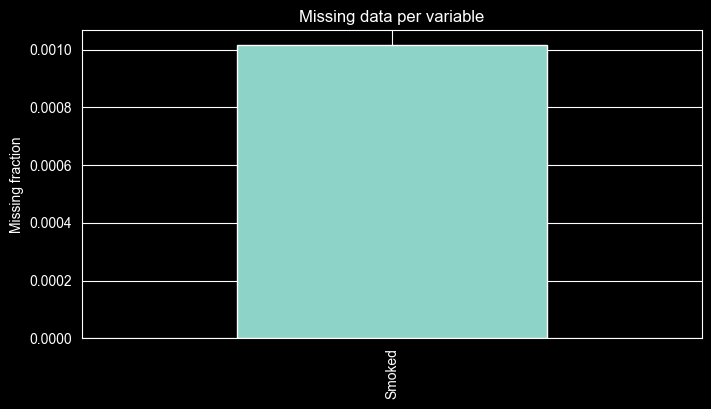

In [6]:
# Missing data analysis
missing = df.isna().mean().sort_values(ascending=False)

plt.figure(figsize=(8,4))
missing[missing > 0].plot(kind="bar")
plt.ylabel("Missing fraction")
plt.title("Missing data per variable")
plt.show()

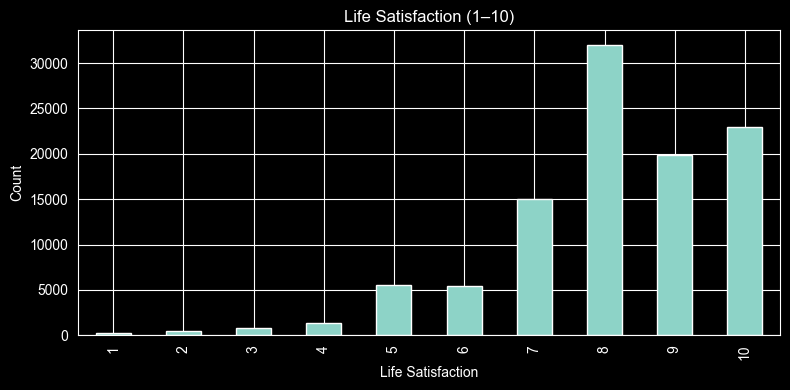

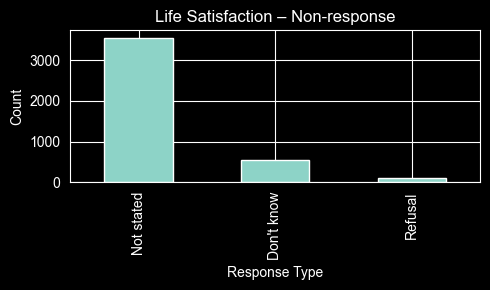

In [4]:
# Exploratory Plots
# Life Satisfaction - target variable
# Plot scale 1-10 responses
life = df["Life_satisfaction"].replace({
    97: "Don't know",
    98: "Refusal",
    99: "Not stated"
})
valid = life[life.apply(lambda x: isinstance(x, (int, float)) and 1 <= x <= 10)]
plt.figure(figsize=(8,4))
valid.value_counts().sort_index().plot(kind="bar")
plt.title("Life Satisfaction (1–10)")
plt.xlabel("Life Satisfaction")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


# Plot non-response categories for life satisfaction
non_response = life[life.isin(["Don't know", "Refusal", "Not stated"])]
plt.figure(figsize=(5,3))
non_response.value_counts().plot(kind="bar")
plt.title("Life Satisfaction – Non-response")
plt.xlabel("Response Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

